In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import os
import pandas as pd
import matplotlib as mpl

In [2]:
pwd

'.../FigureSI3_SSH'

In [3]:
os.chdir('.../')

data = xr.open_dataset('ANHA4_mesh_zgr.nc')
dx = data.variables['e1t']
dy = data.variables['e2t']
e3t = data.variables['e3t_0']
lon = data.variables['nav_lon']
lat = data.variables['nav_lat'] 
bat = data.variables['hdept']
bat = bat[0]

In [4]:
os.chdir('.../outputs_miscellaneous')

vs = np.load('ANHA4-EJM010-S_Average_SSH_20071_201712.npz')
vs = vs['ConvE']
VS = vs/803 #divide by the number of outputs

vd = np.load('ANHA4-EJM012-S_Average_SSH_20071_201712.npz')
vd = vd['ConvE']
VD = vd/803

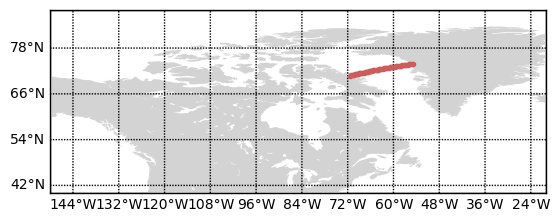

In [7]:
os.chdir('.../')

mask_data = xr.open_dataset('ANHA4_mask.nc')

mask = mask_data.variables['tmask']
mask = mask[0][0]

os.chdir('.../')

dadoss = xr.open_dataset('ANHA4-EJM010_y2017m12d31_gridT.nc')

lat = dadoss.variables['nav_lat_grid_T']
lon = dadoss.variables['nav_lon_grid_T']

lon = np.asarray(lon)
lat = np.asarray(lat)

depth = dadoss.variables['deptht']


#BIG TRANSECT
slat_bb = 485
slon_bb = np.arange(170, 225) 

s1 = slat_bb 
s2 = slon_bb

sec_bb = np.copy(mask)
sec_bb[slat_bb, slon_bb] = 5
sec_bb[np.where(sec_bb != 5)] = np.nan

m = Basemap(projection='cyl', llcrnrlon=-150, llcrnrlat=40, urcrnrlon=-20, urcrnrlat=88, resolution = 'l')

m.drawmeridians(np.arange(0,360,12), labels=[0, 0, 0, 1])
m.drawparallels(np.arange(-90,90,12), labels=[1, 0, 0, 0])
m.drawmapboundary()
m.fillcontinents(color='lightgray')

lons = lon[slat_bb,slon_bb]
lats = lat[slat_bb,slon_bb]

x, y = m(lons,lats)

m.plot(x, y, marker=".",color='indianred')

plt.show()

In [12]:
slat1, slon1 = 485, np.arange(170, 225) 

sec_lat1 = lat[slat1, slon1]
sec_lon1 = lon[slat1, slon1]


sec_vs1 = VS[slat1, slon1]
sec_vd1 = VD[slat1, slon1]

sec_vs1 = np.where(sec_vs1 == 0, np.nan, sec_vs1)
sec_vd1 = np.where(sec_vd1 == 0, np.nan, sec_vd1)

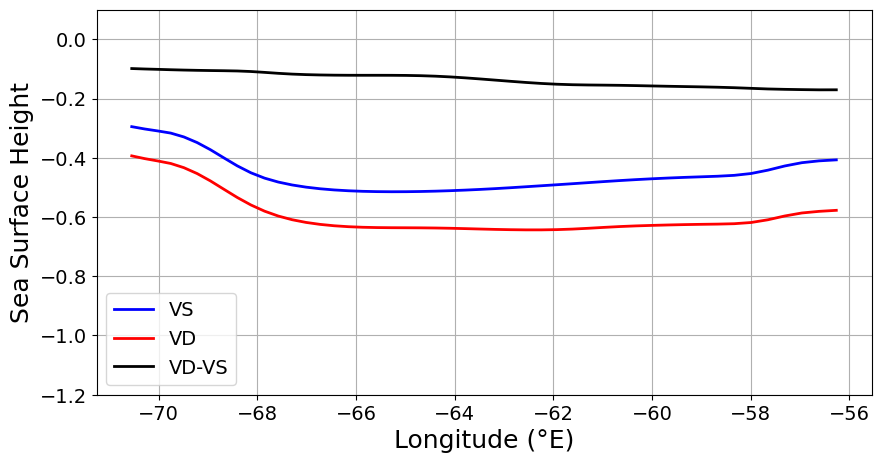

In [13]:
fig, ax = plt.subplots(figsize = (10, 5))

ax.plot(sec_lon1, sec_vs1, color = 'blue', linewidth=2)
ax.plot(sec_lon1, sec_vd1, color = 'red', linewidth=2)
ax.plot(sec_lon1, sec_vd1-sec_vs1, color = 'black', linewidth=2)

ax.legend(['VS', 'VD', 'VD-VS'], fontsize = 14)
plt.xticks( fontsize = 14)
plt.yticks(fontsize=14)
ax.invert_xaxis()
ax.set_ylim(-1.2, 0.1)
ax.grid()
ax.set_xlabel('Longitude (\u00b0E)', fontsize=18)
ax.set_ylabel('Sea Surface Height', fontsize=18)
ax.invert_xaxis()

plt.show()
